# Counts versus fractions: pooled interactions with and without centering

Evaluate the count-based reference experiment alongside both previously trained fraction-based variants and the matching mean-curvature FiLM. Both new models keep accommodation, learned saturation, fixed 1:0.5 ring weights and the same saved outer/inner folds. No training takes place here.

Count exposure is (n_ring1 + 0.5*n_ring2)/1.5; fraction exposure replaces n by each ring's source fraction. The same normalized tanh is used, with F(1)=1. Counts can exceed one, so the response can exceed one before approaching 1/tanh(alpha); amplitudes and saturation parameters are not in directly interchangeable units between representations. Count inputs can encode neighborhood size implicitly.

Compare held-out accuracy overall, by N and by anatomical region. Measure fold consistency of pair-response terms before accommodation on identical sampled neighborhoods, intersecting both count and fraction exposure support across training folds. This is a fitted-term diagnostic, not a fate-replacement ablation or an additional held-out test. Folds share training data; agreement is descriptive. Zero source exposure is a mathematical anchor that can lie outside empirical support.

Keep raw center coefficients separate from full preferences at shared neighborhoods, and save parameters, convergence checks, predictions, support tables and descriptive summaries for later interpretation. The completed fraction-only notebook is preserved in its original training run's source_snapshot/executed_notebooks folder.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import copy
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
from IPython import get_ipython
from IPython.display import display
from src.artifacts.bundle import load_bundle
from src.artifacts.runs import AnalysisRun
from src.artifacts.provenance import workflow_fingerprint
from src.training.coupled_fit import graph_samples
from src.inference.predict import predict_targets
from src.analysis.spatial.regions import distance_regions
torch.set_num_threads(4)

from src.models.coupled_fate import normalized_tanh
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

## Settings
Select the completed run and diagnostic resolution before loading data. Diagnostic sampling uses identity and organoid membership, never measured curvature, predictions or region labels.

In [2]:
# Saved results and execution
TRAINING_RUN = 'training_results/pooled_interaction_training/counts_centered_vs_uncentered_20260930_121245'  # Two-variant training run.
FRACTION_RUN = 'training_results/pooled_interaction_training/centered_vs_uncentered_20260930_112935'  # Existing fraction-based models; never retrained here.
OUTPUT_TAG = 'counts_vs_fractions'  # Analysis folder within the saved run.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Inference backend.

# Fold-consistency sampling and support
SEED = 42  # Reproducible sampling and conditional bootstraps.
CENTERS_PER_IDENTITY_ORGANOID = 12  # Maximum sampled centers per identity and organoid.
SUPPORT_QUANTILES = [.05, .95]  # Intersect fold-specific marginal exposure and size intervals.
MIN_SUPPORT_ORGANOIDS = 20  # Required training and reference organoid support.
N_POINTS = 15  # Supplied size values within common support for each pair.
RESPONSE_FLOOR = .0001  # Flag near-zero RMS responses in physical mean-curvature units.

# Accuracy summaries and anatomical definitions
BOOTSTRAP_DRAWS = 2000  # Paired organoid draws; no retraining uncertainty.
CRYPT_MAX = .75  # Crypt interior regardless of circumference profile.
NECK_MAX = 1.1  # Qualified neck upper boundary; villus begins here.
CRYPT_MARKER = 'LGR5'  # Exclusive interior marker defining crypt subtypes.

## Restore matched models
Verify exact outer memberships and identical inner splits for all four count/fraction variants. Restore both earlier fraction models and the matching FiLM weights; no reference models are retrained.

In [3]:
run = AnalysisRun(PROJECT_ROOT/TRAINING_RUN)
if not (run.directory/'complete.json').exists():raise ValueError('Training is incomplete')
source = AnalysisRun(run.settings['source_run'])
fraction_run = AnalysisRun(PROJECT_ROOT/FRACTION_RUN)
membership = json.loads((run.directory/'splits.json').read_text())
if membership != json.loads((source.directory/'splits.json').read_text()):raise ValueError('Outer fold mismatch')
if membership != json.loads((fraction_run.directory/'splits.json').read_text()):raise ValueError('Fraction/count outer fold mismatch')
cohort = load_bundle(run.directory/'cohort')
marker_names = list(cohort['all_marker_names'])
identity_names = marker_names+['Unassigned']
OUTPUT_DIR = run.directory/'analysis'/OUTPUT_TAG
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
(OUTPUT_DIR/'predictions').mkdir(exist_ok=True)
settings = dict(training_run=str(run.directory),fraction_run=str(fraction_run.directory),source_run=str(source.directory),device=DEVICE,seed=SEED,
    centers_per_identity_organoid=CENTERS_PER_IDENTITY_ORGANOID,support_quantiles=SUPPORT_QUANTILES,
    min_support_organoids=MIN_SUPPORT_ORGANOIDS,n_points=N_POINTS,response_floor=RESPONSE_FLOOR,
    bootstrap_draws=BOOTSTRAP_DRAWS,crypt_max=CRYPT_MAX,neck_max=NECK_MAX,crypt_marker=CRYPT_MARKER,
    code_sha256=workflow_fingerprint(PROJECT_ROOT/'legacy/energy_models/notebooks/benchmarks/pooled_interaction_evaluation.ipynb'))
(OUTPUT_DIR/'settings.json').write_text(json.dumps(settings,indent=2))
models = {}
for split in membership:
    fold = split['fold']
    fitted = []
    for family,saved_run in [('counts',run),('fractions',fraction_run)]:
        for centered in [True,False]:
            suffix = 'centered' if centered else 'uncentered'
            name = family+'_'+suffix
            rows = saved_run.records[(saved_run.records.name=='pooled_'+suffix)&(saved_run.records.fold==fold)]
            if len(rows)!=1:raise ValueError('Ambiguous pooled checkpoint')
            payload = load_bundle(saved_run.directory/rows.iloc[0].bundle)
            model = payload['model']
            if model.exposure_kind != ('counts' if family=='counts' else 'fractions') or model.center_response!=centered:
                raise ValueError('Wrong exposure or centering in checkpoint')
            models[name,fold] = model
            fitted.append(payload['metrics'])
    for field in ['inner_train','inner_validation','fit_organoids']:
        if any(f[field]!=fitted[0][field] for f in fitted[1:]):raise ValueError('Different fitting membership')
model_names = ['fractions_centered','counts_centered','fractions_uncentered','counts_uncentered']
colors = dict(fractions_centered='tab:blue',counts_centered='tab:orange',fractions_uncentered='tab:green',counts_uncentered='tab:red',FiLM='0.35')
print('Restored',len(models),'energy models; existing FiLM loaded per fold below.')


Restored 20 energy models; existing FiLM loaded per fold below.


## Held-out predictions and anatomy
Reconstruct regions directly from graph crypt distances and circumference profiles. Save full-curvature predictions by restoring the identical baseline, and verify that regional errors reconstruct total MSE. Collect a fixed sample of fate neighborhoods for separate parameter diagnostics.

In [4]:
scores = []
reference_rows = []
reference_counts = []
rng = np.random.default_rng(SEED)
region_tables = []
for split in membership:
    fold = split['fold']
    physical = load_bundle(run.directory/f'inputs/fold_{fold}_mean')
    graphs = physical['groups']['val']
    if [g.organoid_str for g in graphs]!=split['validation']:raise ValueError('Validation ordering mismatch')
    samples = graph_samples(graphs,2)
    annotations = {}
    for g,sample in zip(graphs,samples):
        raw = copy.deepcopy(cohort['raw_graphs'][g.organoid_str])
        raw.x = g.x.clone()
        table = distance_regions(raw,PROJECT_ROOT/'training_data'/run.settings['dataset'],marker_names=marker_names,
            crypt_marker=CRYPT_MARKER,crypt_max=CRYPT_MAX,neck_max=NECK_MAX)
        annotations[g.organoid_str] = table.region.to_numpy()
        region_tables.append(table)
        for a in np.unique(sample['identity']):
            eligible = np.flatnonzero(sample['identity']==a)
            selected = np.sort(rng.choice(eligible,min(len(eligible),CENTERS_PER_IDENTITY_ORGANOID),replace=False))
            reference_counts.append(sample['counts'][selected])
            reference_rows.extend(dict(organoid_str=g.organoid_str,node=int(i),identity=int(a),N=sample['N'],heldout_fold=fold) for i in selected)
    features = [{k:v for k,v in s.items() if k!='y'} for s in samples]
    predictions = {name:models[name,fold].predict_samples(features,device=DEVICE) for name in model_names}
    fr = source.records[(source.records.name=='FiLM')&(source.records.fold==fold)]
    if len(fr)!=1:raise ValueError('Ambiguous FiLM checkpoint')
    fr = fr.iloc[0]
    film = load_bundle(source.directory/fr.bundle)['model']
    inputs = load_bundle(source.directory/fr.input_bundle)
    if [g.organoid_str for g in inputs['groups']['val']]!=split['validation']:raise ValueError('FiLM membership mismatch')
    _,pred,_ = predict_targets(inputs['groups']['val'],film,target_transform=inputs['transform'],device=DEVICE)
    offsets = np.r_[0,np.cumsum([len(g.x) for g in graphs])]
    predictions['FiLM'] = [np.asarray(pred)[a:b].reshape(-1) for a,b in zip(offsets[:-1],offsets[1:])]
    predictions['Baseline'] = [np.zeros(len(g.x)) for g in graphs]
    for name,arrays in predictions.items():
        truth_saved = []
        pred_saved = []
        for g,pred in zip(graphs,arrays):
            residual = g.y.numpy().reshape(-1)
            if not np.isfinite(pred).all():raise ValueError('Nonfinite prediction')
            error = (pred-residual)**2
            region = annotations[g.organoid_str]
            reconstructed = 0.
            for label in ['total',*np.unique(region)]:
                take = np.ones(len(error),bool) if label=='total' else region==label
                mse = float(error[take].mean())
                scores.append(dict(name=name,fold=fold,organoid_str=g.organoid_str,N=len(g.x),region=label,mse=mse))
                if label!='total':reconstructed+=mse*take.mean()
            if not np.isclose(reconstructed,error.mean(),rtol=1e-10,atol=1e-12):raise ValueError('Region reconstruction failed')
            baseline = np.asarray(physical['baseline_offsets'][g.organoid_str]).reshape(-1)
            truth_saved.append(residual+baseline)
            pred_saved.append(pred+baseline)
        np.savez_compressed(OUTPUT_DIR/'predictions'/f'{name}_f{fold}.npz',prediction=np.concatenate(pred_saved),
            truth=np.concatenate(truth_saved),offsets=offsets,organoid_ids=np.asarray(split['validation']))
    print('Evaluated fold',fold,flush=True)
scores = pd.DataFrame(scores)
scores.to_csv(OUTPUT_DIR/'validation_mse.csv',index=False)
regions = pd.concat(region_tables,ignore_index=True)
regions.to_csv(OUTPUT_DIR/'regions.csv.gz',index=False)
reference = pd.DataFrame(reference_rows)
counts = np.concatenate(reference_counts)
reference.to_csv(OUTPUT_DIR/'reference_centers.csv.gz',index=False)
np.savez_compressed(OUTPUT_DIR/'reference_features.npz',counts=counts,identity=reference.identity.to_numpy())
summary = scores.groupby(['name','region']).mse.agg(['mean','sem','count']).reset_index()
summary.to_csv(OUTPUT_DIR/'mse_summary.csv',index=False)

# Reproduce saved count/fraction and FiLM scores from restored checkpoints.
reference_audits = []
for saved_run,pairs in [(run,[('pooled_centered','counts_centered'),('pooled_uncentered','counts_uncentered')]),
                         (fraction_run,[('pooled_centered','fractions_centered'),('pooled_uncentered','fractions_uncentered')]),
                         (source,[('FiLM','FiLM')])]:
    previous_scores = pd.read_csv(saved_run.directory/'validation_mse.csv')
    for old_name,new_name in pairs:
        old = previous_scores[previous_scores.name==old_name].set_index(['fold','organoid_str']).mse
        new = scores[(scores.name==new_name)&(scores.region=='total')].set_index(['fold','organoid_str']).mse
        if set(old.index)!=set(new.index):raise ValueError('Reference membership changed')
        difference = float((new-old).abs().max())
        if difference>1e-8:raise ValueError(f'Reference predictions changed: {new_name}, {difference}')
        reference_audits.append(dict(model=new_name,max_absolute_organoid_mse_difference=difference))
(OUTPUT_DIR/'reference_audit.json').write_text(json.dumps(reference_audits,indent=2))


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:119: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Evaluated fold 0


Evaluated fold 1


Evaluated fold 2


Evaluated fold 3


Evaluated fold 4


537

## Predictive accuracy
Plot organoid-weighted MSE overall, by region and by observed size, with one-SEM bands. Paired bootstrap differences use the same held-out organoids and condition on fitted models. They exclude retraining uncertainty.

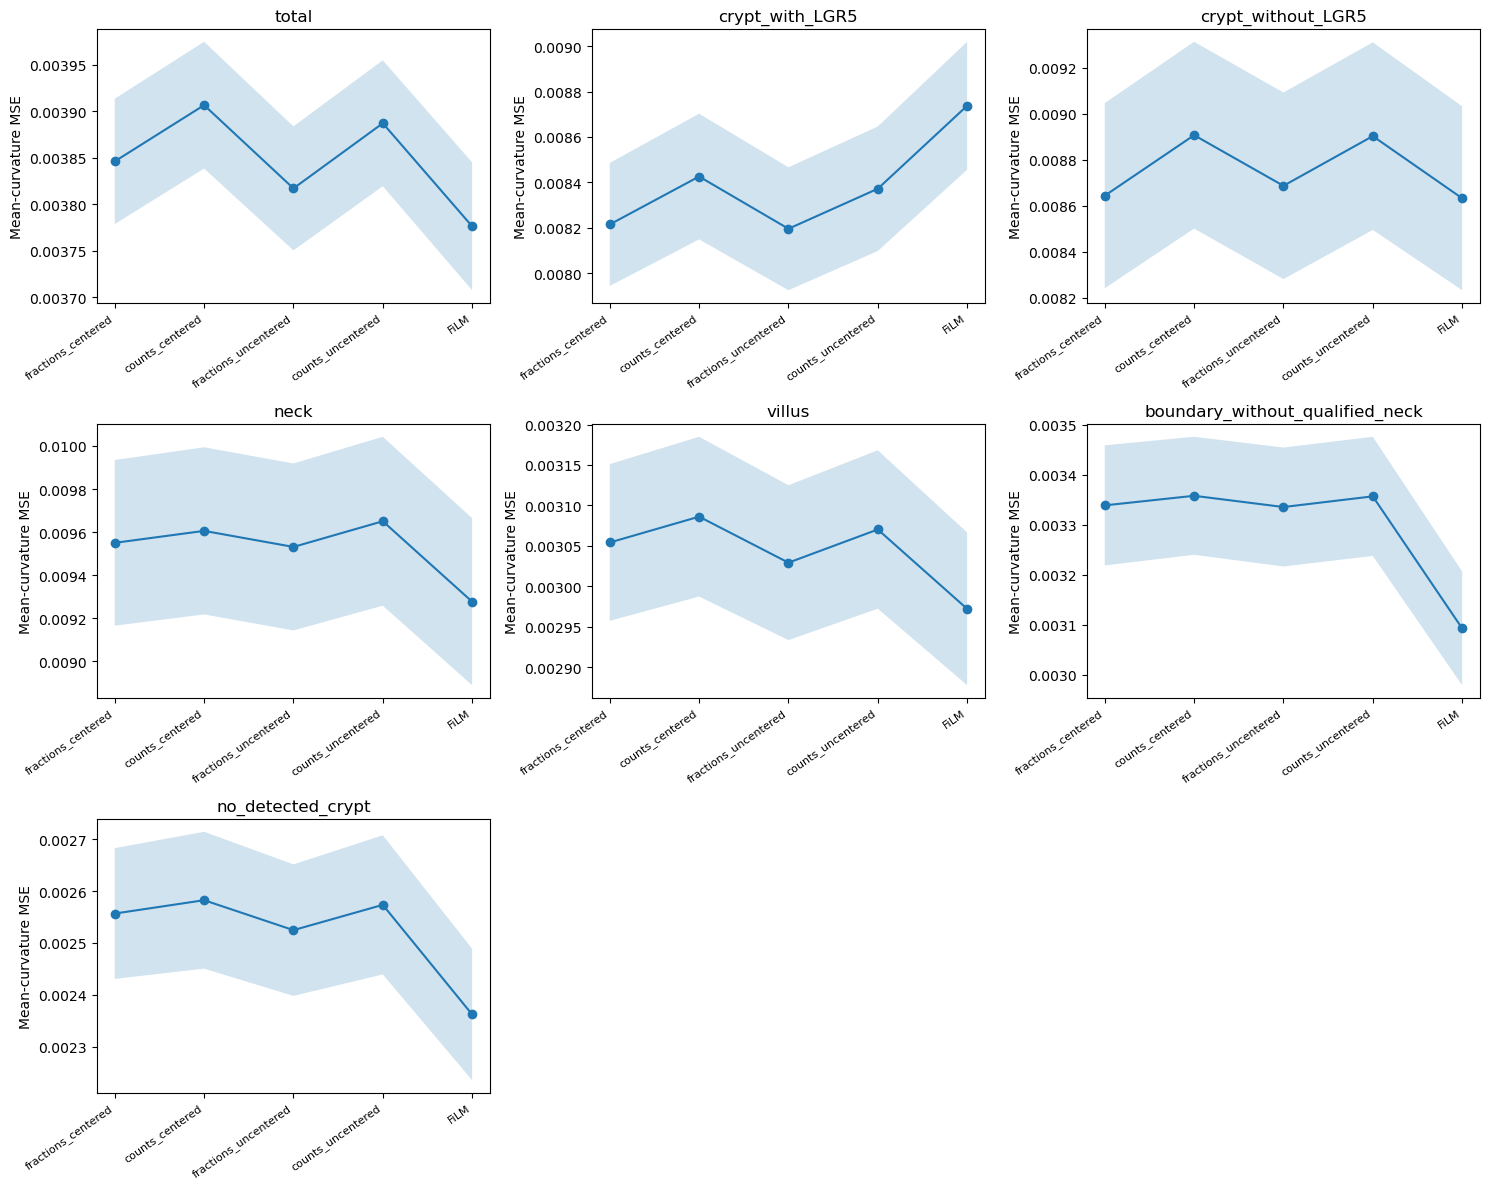

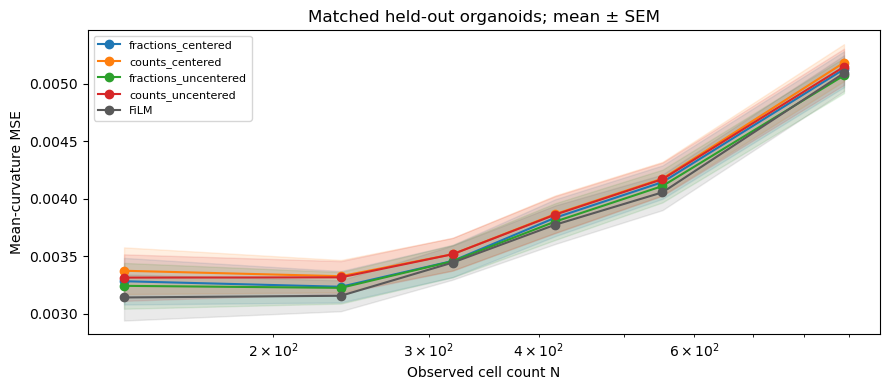

In [5]:
order = model_names+['FiLM']
labels = ['total','crypt_with_LGR5','crypt_without_LGR5','neck','villus','boundary_without_qualified_neck','no_detected_crypt']
labels = [r for r in labels if r in set(summary.region)]
fig,axes = plt.subplots(int(np.ceil(len(labels)/3)),3,figsize=(15,4*int(np.ceil(len(labels)/3))),squeeze=False)
for ax,label in zip(axes.flat,labels):
    d = summary[summary.region==label].set_index('name').reindex(order)
    x = np.arange(len(order))
    ax.plot(x,d['mean'],'o-')
    ax.fill_between(x,d['mean']-d['sem'],d['mean']+d['sem'],alpha=.2)
    ax.set_xticks(x,order,rotation=35,ha='right',fontsize=8)
    ax.set(title=label,ylabel='Mean-curvature MSE')
for ax in list(axes.flat)[len(labels):]:ax.set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR/'mse_by_region.png',dpi=160)
plt.show()
total = scores[scores.region=='total'].copy()
unique = total.drop_duplicates('organoid_str')
edges = np.unique(np.quantile(unique.N,np.linspace(0,1,7)))
total['size_bin'] = pd.cut(total.N,edges,include_lowest=True)
size_table = total.groupby(['name','size_bin'],observed=True).agg(N=('N','mean'),mean=('mse','mean'),sem=('mse','sem'),count=('mse','size')).reset_index()
size_table.to_csv(OUTPUT_DIR/'mse_by_size.csv',index=False)
fig,ax = plt.subplots(figsize=(9,4))
for name in order:
    d = size_table[size_table.name==name]
    ax.plot(d.N,d['mean'],'o-',label=name,color=colors[name])
    ax.fill_between(d.N,d['mean']-d['sem'],d['mean']+d['sem'],alpha=.12,color=colors[name])
ax.set(xscale='log',xlabel='Observed cell count N',ylabel='Mean-curvature MSE',title='Matched held-out organoids; mean ± SEM')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR/'mse_by_size.png',dpi=160)
plt.show()
paired = []
rng = np.random.default_rng(SEED)
for name,ref_name in [('counts_centered','fractions_centered'),('counts_uncentered','fractions_uncentered'),
                      ('counts_uncentered','counts_centered'),('counts_centered','FiLM'),('counts_uncentered','FiLM')]:
    a = total[total.name==name].set_index('organoid_str').mse
    b = total[total.name==ref_name].set_index('organoid_str').mse
    if set(a.index)!=set(b.index):raise ValueError('Unpaired organoids')
    delta = (a-b).to_numpy()
    draws = np.array([rng.choice(delta,len(delta),replace=True).mean() for _ in range(BOOTSTRAP_DRAWS)])
    paired.append(dict(model=name,reference=ref_name,difference=delta.mean(),ci_low=np.quantile(draws,.025),ci_high=np.quantile(draws,.975)))
paired = pd.DataFrame(paired)
paired.to_csv(OUTPUT_DIR/'paired_comparisons.csv',index=False)


## Pair-response consistency on identical contexts

For each center/source pair, retain positive-source neighborhoods in the intersection of training folds' 5–95% marginal ranges of both count/fraction exposures and observed N. Bounds are estimated from the saved fate-only reference sample. Require at least 20 supporting training organoids per fold and 20 retained reference organoids. This checks marginal support, not joint support of every swept combination.

Read out the local pair contribution relative to zero source exposure: beta(N)*F(x), using each model's own exposure representation on identical neighborhoods. Reference offsets cancel. These are individual-term diagnostics before accommodation, not full-prediction or fate-replacement ablations. The zero-exposure anchor can lie outside empirical support; it is a model-defined reference.

Every fold sees exactly the same contexts, equally weighting organoids. Relative dispersion is RMS deviation from the fold mean divided by RMS of all fold responses (0 means identical; values near 1 mean strong disagreement). Also export absolute dispersion, response size, individual-context dispersion, sign/trend agreement and saturation range. Flag negligible responses rather than interpreting their ratios. These shared-cohort diagnostics include training contexts for some folds; only the earlier MSE section measures held-out prediction quality.

In [6]:
identity = reference.identity.to_numpy()
orgs = reference.organoid_str.to_numpy()
observed_N = reference.N.to_numpy()
pooled_template = models['counts_centered',membership[0]['fold']]
sample_all = dict(identity=identity,counts=counts)
exposure = pooled_template.exposure(sample_all)
fraction_exposure = models['fractions_centered',membership[0]['fold']].exposure(sample_all)
response_cache = {key:m.combine_response(m.raw_response(sample_all),identity) for key,m in models.items()}
train_masks = {s['fold']:reference.organoid_str.isin(s['train']).to_numpy() for s in membership}
curve_rows = []
stability_rows = []
support_rows = []
parameter_rows = []
center_rows = []
folds = [s['fold'] for s in membership]
common_ns = np.geomspace(unique.N.quantile(.05),unique.N.quantile(.95),N_POINTS)
for (name,fold),m in models.items():
    co = m.coefficients(common_ns)
    amplitude = co['amplitude' if m.interaction=='pooled' else 'hop1']
    for a,A in enumerate(identity_names):
        center_rows.append(dict(name=name,fold=fold,center=A,preference=co['center'][0,a]))
        for b,B in enumerate(identity_names):
            for j,n in enumerate(common_ns):
                parameter_rows.append(dict(name=name,fold=fold,center=A,source=B,N=n,amplitude=amplitude[j,a,b],
                    alpha=m.alpha()[a,b],support=int(m.pair_support[a,b]),reference_mean=float(m.reference[a,0,b]),
                    relative_hop_sign=int(m.signs[a,b]) if m.interaction=='signed_hops' else 1))
for a,A in enumerate(identity_names):
    for b,B in enumerate(identity_names):
        eligible = (identity==a)&(counts[:,:,b].sum(1)>0)
        bounds = []
        for fold in folds:
            selected = eligible&train_masks[fold]
            if not selected.any():break
            xlo,xhi = np.quantile(exposure[selected,b],SUPPORT_QUANTILES)
            nlo,nhi = np.quantile(reference.loc[selected,['organoid_str','N']].drop_duplicates('organoid_str').N,SUPPORT_QUANTILES)
            flo,fhi = np.quantile(fraction_exposure[selected,b],SUPPORT_QUANTILES)
            bounds.append((xlo,xhi,nlo,nhi,flo,fhi))
        if len(bounds)!=len(folds):continue
        xlo=max(v[0] for v in bounds);xhi=min(v[1] for v in bounds)
        nlo=max(v[2] for v in bounds);nhi=min(v[3] for v in bounds)
        flo=max(v[4] for v in bounds);fhi=min(v[5] for v in bounds)
        selected = eligible&(exposure[:,b]>=xlo)&(exposure[:,b]<=xhi)&(fraction_exposure[:,b]>=flo)&(fraction_exposure[:,b]<=fhi)&(observed_N>=nlo)&(observed_N<=nhi)
        selected_orgs,org_index,org_counts = np.unique(orgs[selected],return_inverse=True,return_counts=True)
        min_train = min(int(m.pair_support[a,b]) for m in models.values())
        supported = len(selected_orgs)>=MIN_SUPPORT_ORGANOIDS and min_train>=MIN_SUPPORT_ORGANOIDS and nhi>nlo and xhi>=xlo and fhi>=flo
        support_rows.append(dict(center=A,source=B,organoids=len(selected_orgs),cells=int(selected.sum()),min_training_organoids=min_train,
            count_low=xlo,count_high=xhi,fraction_low=flo,fraction_high=fhi,N_low=nlo,N_high=nhi,supported=supported))
        if not supported:continue
        weights = 1/(len(selected_orgs)*org_counts[org_index])
        ns = np.geomspace(nlo,nhi,N_POINTS)
        for name in model_names:
            fold_curves = []
            individual = []
            alphas = []
            for fold in folds:
                m = models[name,fold]
                co = m.coefficients(ns)
                beta = co['amplitude' if m.interaction=='pooled' else 'hop1'][:,a,b]
                values = beta[:,None]*response_cache[name,fold][selected,b][None,:]
                curve = values@weights
                fold_curves.append(curve);individual.append(values);alphas.append(m.alpha()[a,b])
                curve_rows.extend(dict(name=name,fold=fold,center=A,source=B,N=n,response=v) for n,v in zip(ns,curve))
            fold_curves = np.asarray(fold_curves)
            individual = np.asarray(individual)
            mean = fold_curves.mean(0)
            rms = np.sqrt(np.mean(fold_curves**2))
            absolute = np.sqrt(np.mean((fold_curves-mean)**2))
            individual_rms = np.sqrt(np.mean(np.sum(individual**2*weights,axis=2)))
            individual_sd = np.sqrt(np.mean(np.sum((individual-individual.mean(0))**2*weights,axis=2)))
            votes = np.maximum((fold_curves>RESPONSE_FLOOR).sum(0),(fold_curves<-RESPONSE_FLOOR).sum(0))/len(folds)
            endpoint = fold_curves[:,-1]-fold_curves[:,0]
            trend_agreement = max((endpoint>RESPONSE_FLOOR).sum(),(endpoint<-RESPONSE_FLOOR).sum())/len(folds)
            stability_rows.append(dict(name=name,center=A,source=B,response_rms=rms,absolute_fold_rms=absolute,
                relative_dispersion=absolute/rms if rms>0 else np.nan,near_zero=rms<RESPONSE_FLOOR,
                individual_response_rms=individual_rms,individual_relative_dispersion=individual_sd/individual_rms if individual_rms>0 else np.nan,
                mean_sign_agreement=votes.mean(),all_signs_agree=bool(np.all(votes==1)),trend_sign_agreement=trend_agreement,
                endpoint_rms=float(np.sqrt(np.mean(endpoint**2))),alpha_min=min(alphas),alpha_max=max(alphas),
                alpha_ratio=max(alphas)/min(alphas),alpha_bound_count=sum(x<=.0201 or x>=99. for x in alphas)))
curves = pd.DataFrame(curve_rows)
stability = pd.DataFrame(stability_rows)
support = pd.DataFrame(support_rows)
parameters = pd.DataFrame(parameter_rows)
centers = pd.DataFrame(center_rows)
for filename,frame in [('response_curves',curves),('pair_stability',stability),('pair_support',support),('parameters',parameters),('center_preferences',centers)]:
    frame.to_csv(OUTPUT_DIR/f'{filename}.csv',index=False)
print('Supported diagnostic pairs:',int(support.supported.sum()),'/',len(support))


Supported diagnostic pairs: 64 / 64


## Fold consistency and response curves
Compare models on identical supported pairs. Hatching indicates insufficient support and cyan dots flag near-zero responses. Thin curves show individual folds and thick curves their mean; all curves use local preferred mean-curvature units. Relative dispersion must be read with response size and absolute disagreement in the exported tables.

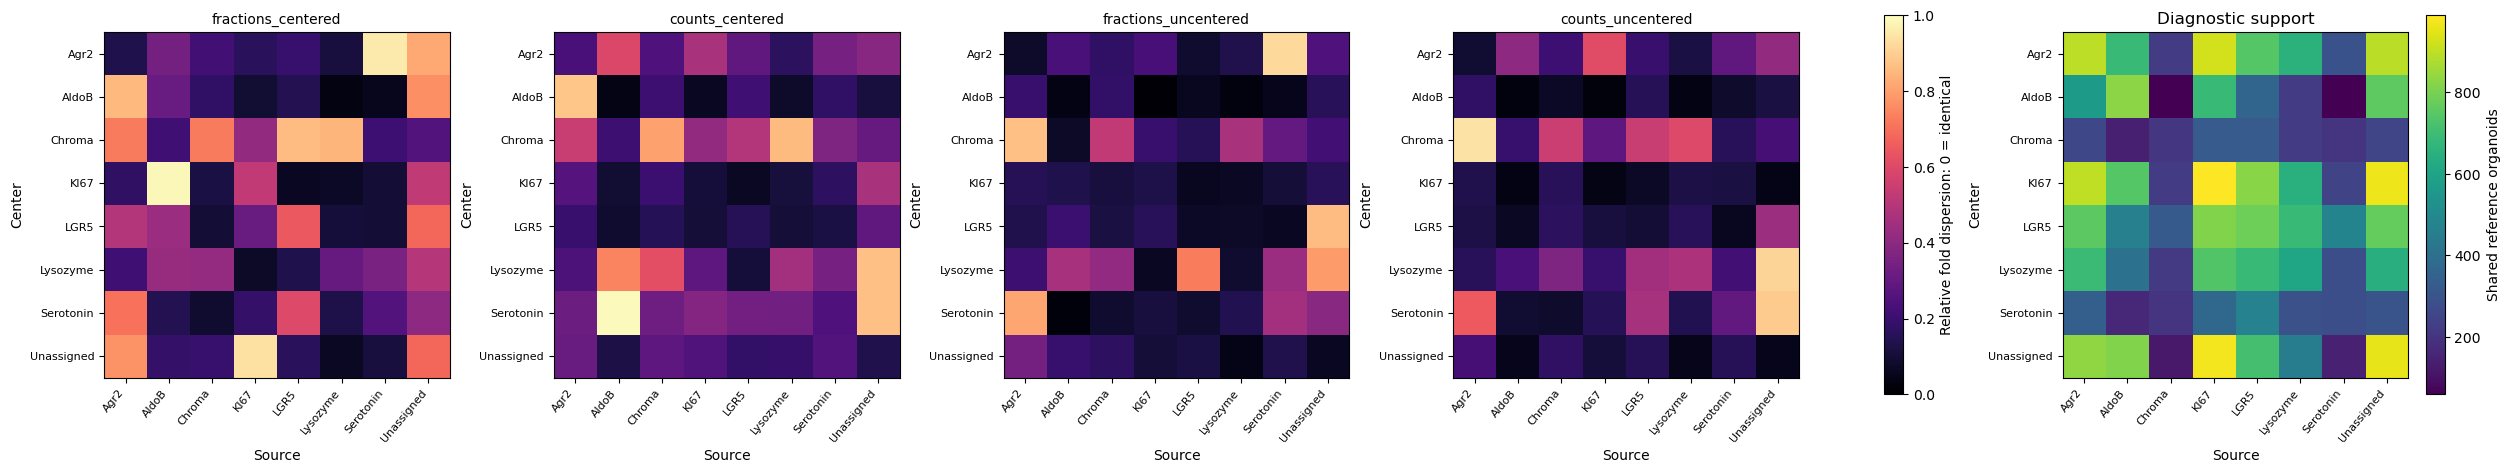

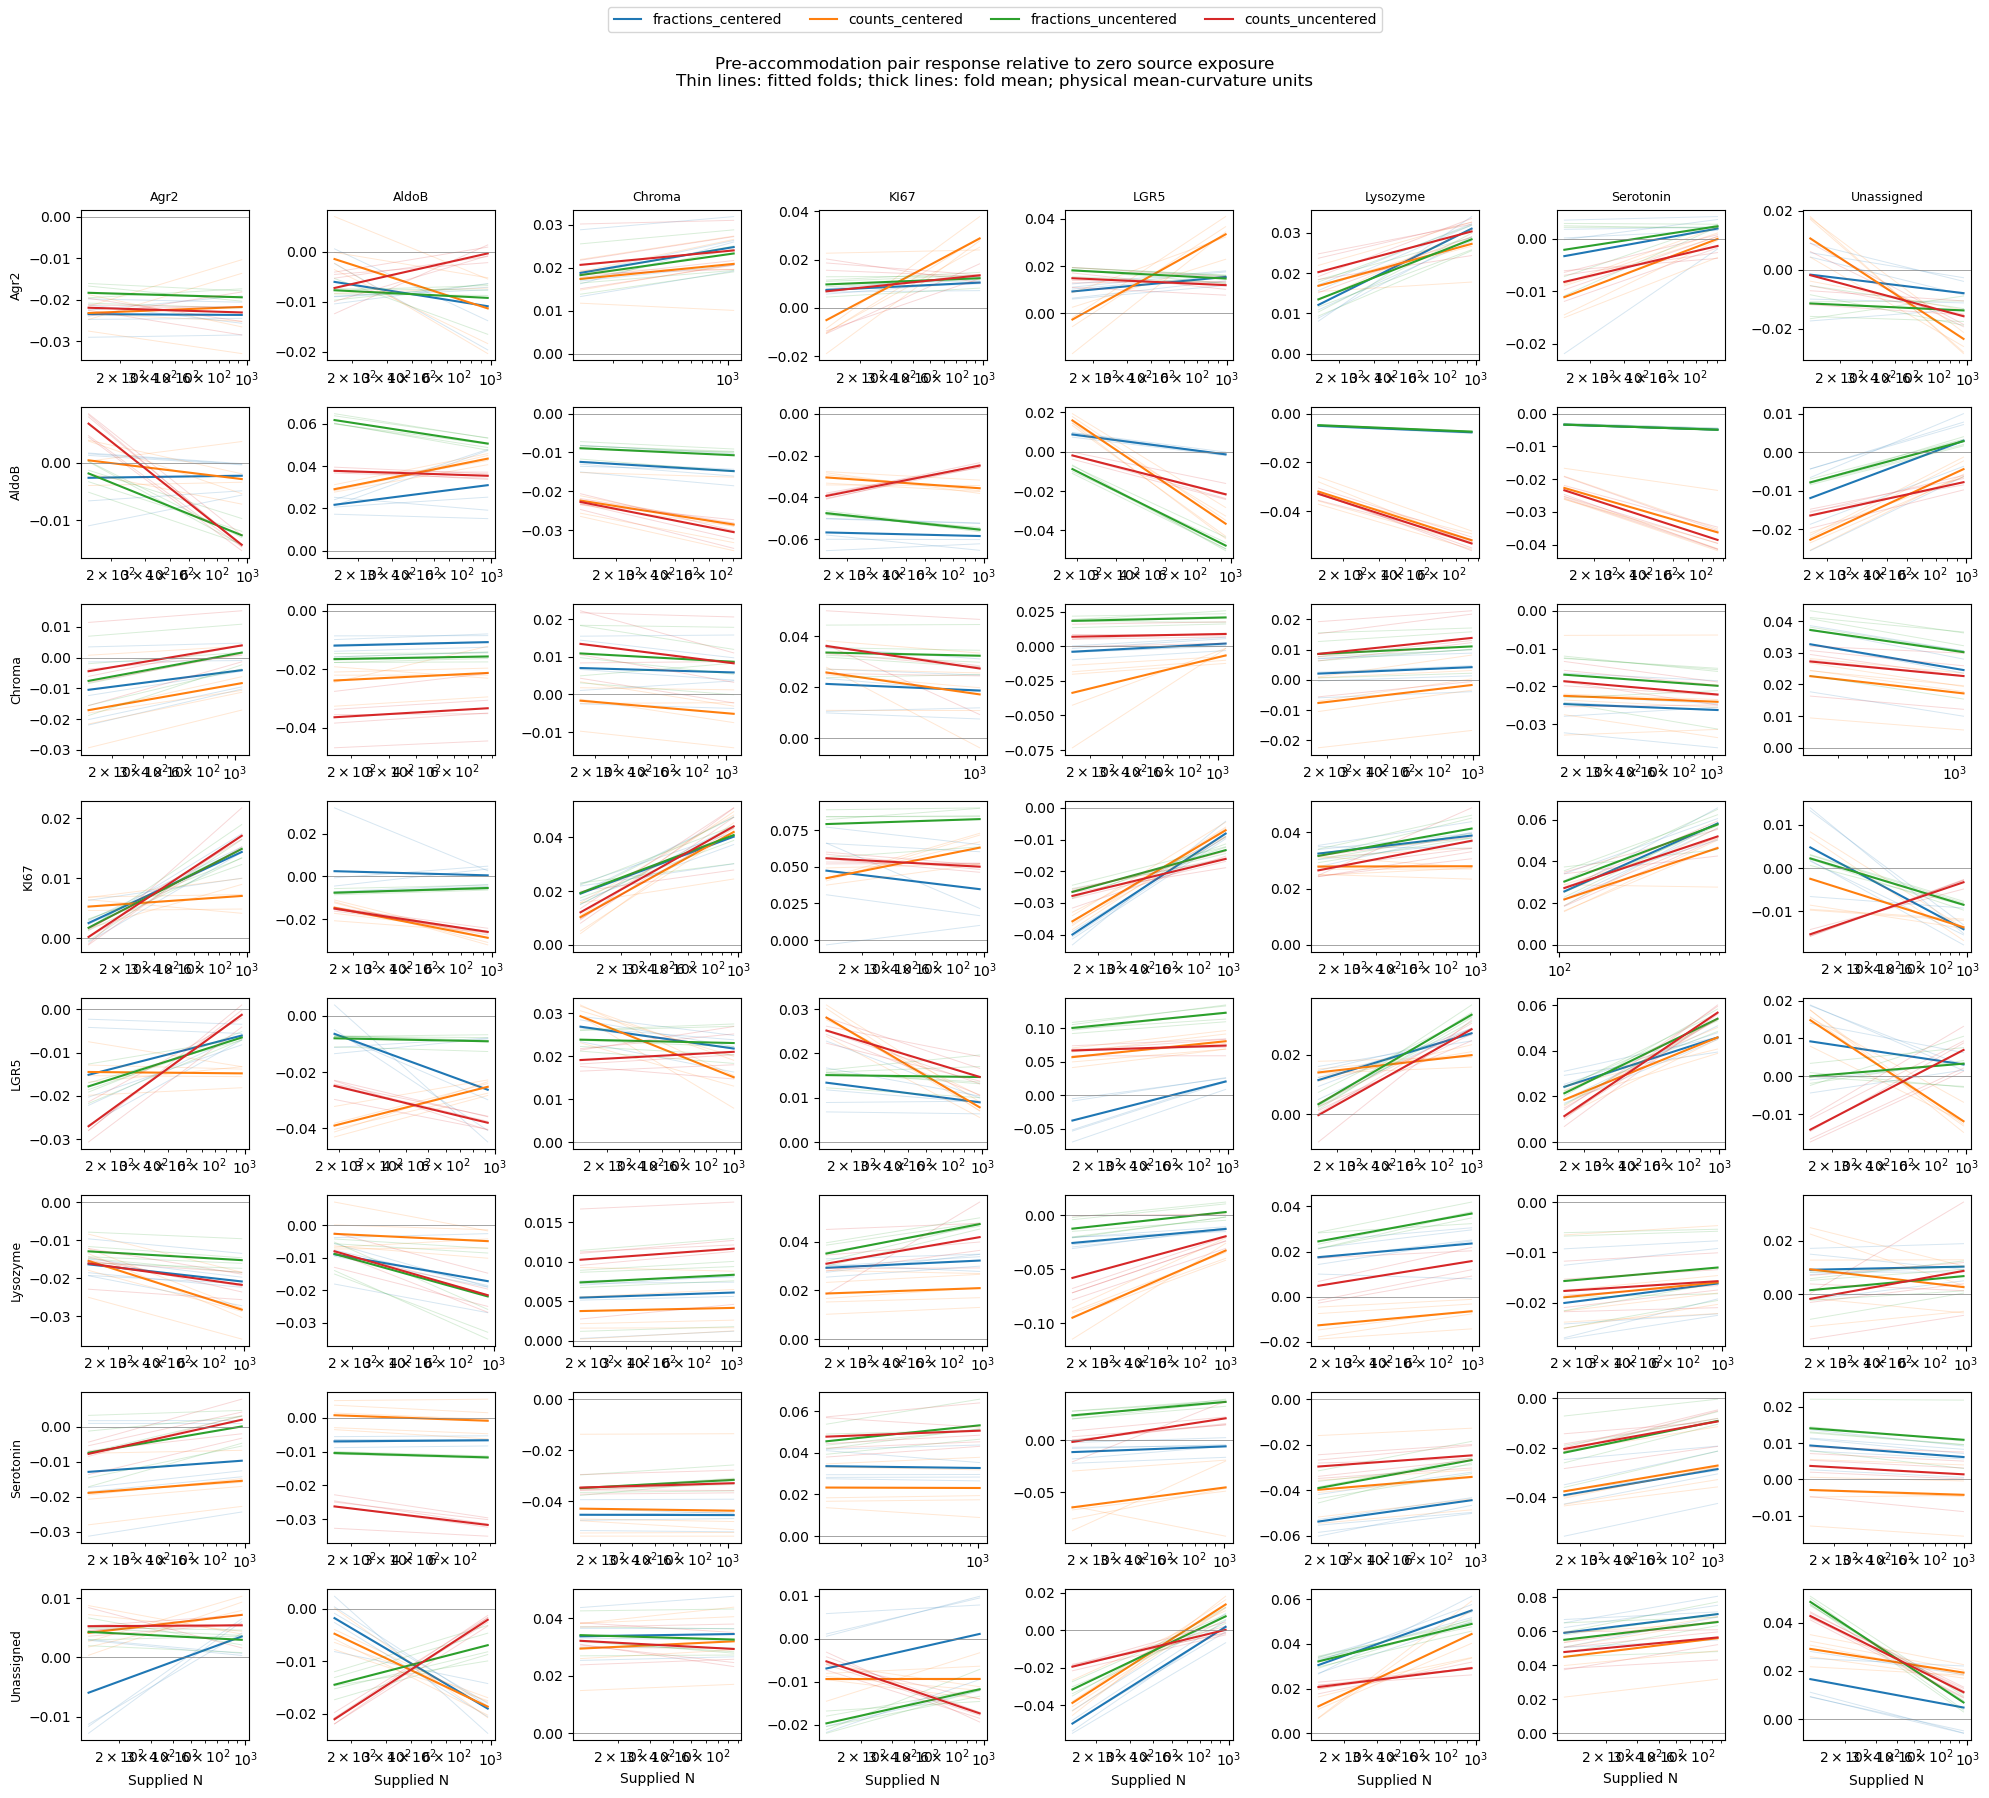

In [7]:
fig,axes = plt.subplots(1,5,figsize=(25,5.5),layout='constrained')
t = len(identity_names)
for ax,name in zip(axes[:-1],model_names):
    d = stability[stability.name==name]
    matrix = d.pivot(index='center',columns='source',values='relative_dispersion').reindex(index=identity_names,columns=identity_names)
    im = ax.imshow(matrix,vmin=0,vmax=1,cmap='magma')
    for a,A in enumerate(identity_names):
        for b,B in enumerate(identity_names):
            cell = d[(d.center==A)&(d.source==B)]
            if cell.empty:ax.add_patch(Rectangle((b-.5,a-.5),1,1,fill=False,hatch='///',edgecolor='gray',lw=0))
            elif bool(cell.near_zero.iloc[0]):ax.plot(b,a,'.',color='cyan',ms=5)
    ax.set_title(name,fontsize=10)
fig.colorbar(im,ax=list(axes[:-1]),label='Relative fold dispersion: 0 = identical',shrink=.7)
matrix = support.pivot(index='center',columns='source',values='organoids').reindex(index=identity_names,columns=identity_names)
im = axes[-1].imshow(matrix,cmap='viridis')
fig.colorbar(im,ax=axes[-1],label='Shared reference organoids',shrink=.7)
axes[-1].set_title('Diagnostic support')
for ax in axes:
    ax.set_xticks(np.arange(t),identity_names,rotation=50,ha='right',fontsize=8)
    ax.set_yticks(np.arange(t),identity_names,fontsize=8)
    ax.set(xlabel='Source',ylabel='Center')
fig.savefig(OUTPUT_DIR/'fold_consistency.png',dpi=160,bbox_inches='tight')
plt.show()
fig,axes = plt.subplots(t,t,figsize=(20,18),sharex=False)
for a,A in enumerate(identity_names):
    for b,B in enumerate(identity_names):
        ax = axes[a,b]
        for name in model_names:
            d = curves[(curves.name==name)&(curves.center==A)&(curves.source==B)]
            if d.empty:continue
            for fold,g in d.groupby('fold'):
                ax.plot(g.N,g.response,color=colors[name],alpha=.18,lw=.7)
            mean = d.groupby('N').response.mean()
            ax.plot(mean.index,mean.values,color=colors[name],label=name,lw=1.5)
        ax.axhline(0,color='gray',lw=.5)
        ax.set_xscale('log')
        if a==0:ax.set_title(B,fontsize=9)
        if b==0:ax.set_ylabel(A,fontsize=9)
        if a==t-1:ax.set_xlabel('Supplied N')
handles,labels_ = next((ax.get_legend_handles_labels() for ax in axes.flat if ax.get_legend_handles_labels()[0]))
fig.legend(handles,labels_,loc='upper center',ncol=4)
fig.suptitle('Pre-accommodation pair response relative to zero source exposure\nThin lines: fitted folds; thick lines: fold mean; physical mean-curvature units',y=.97)
fig.tight_layout(rect=(0,0,1,.93))
fig.savefig(OUTPUT_DIR/'pair_response_curves.png',dpi=150)
plt.show()


## Center preferences and saturation
Raw center coefficients have different reference conventions. Compare them with the full local preferred field at identical empirical contexts and one common N. Error bars are descriptive fold standard deviations. Plot accommodation for every fold and saturation variability across folds; none of these parameters is an independently measured mechanical or biochemical constant.

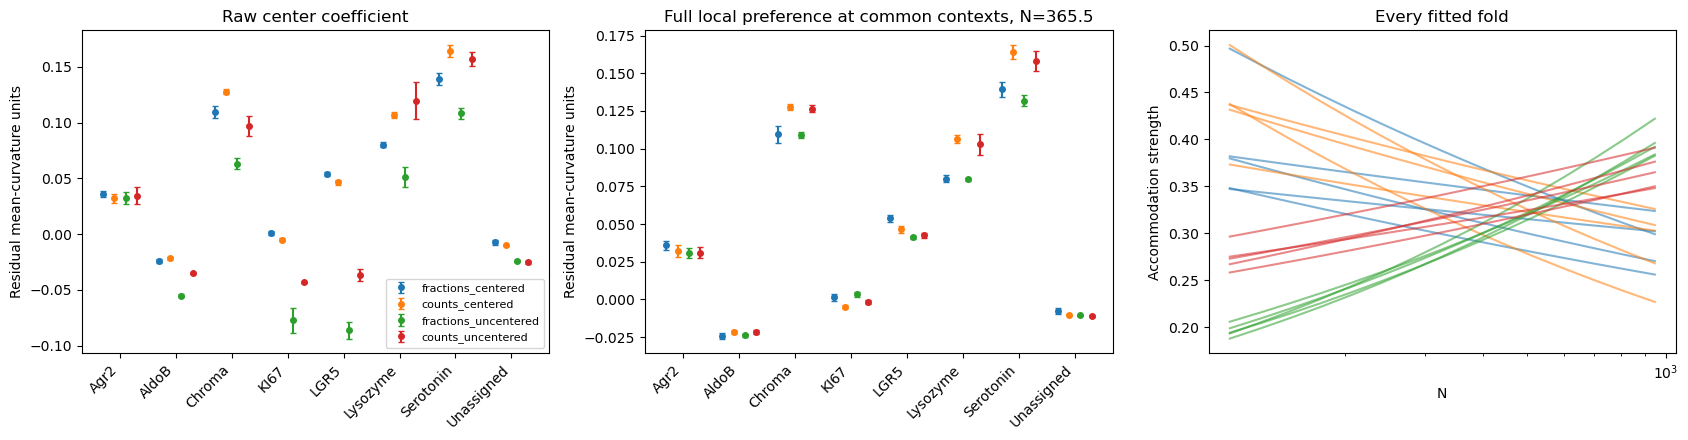

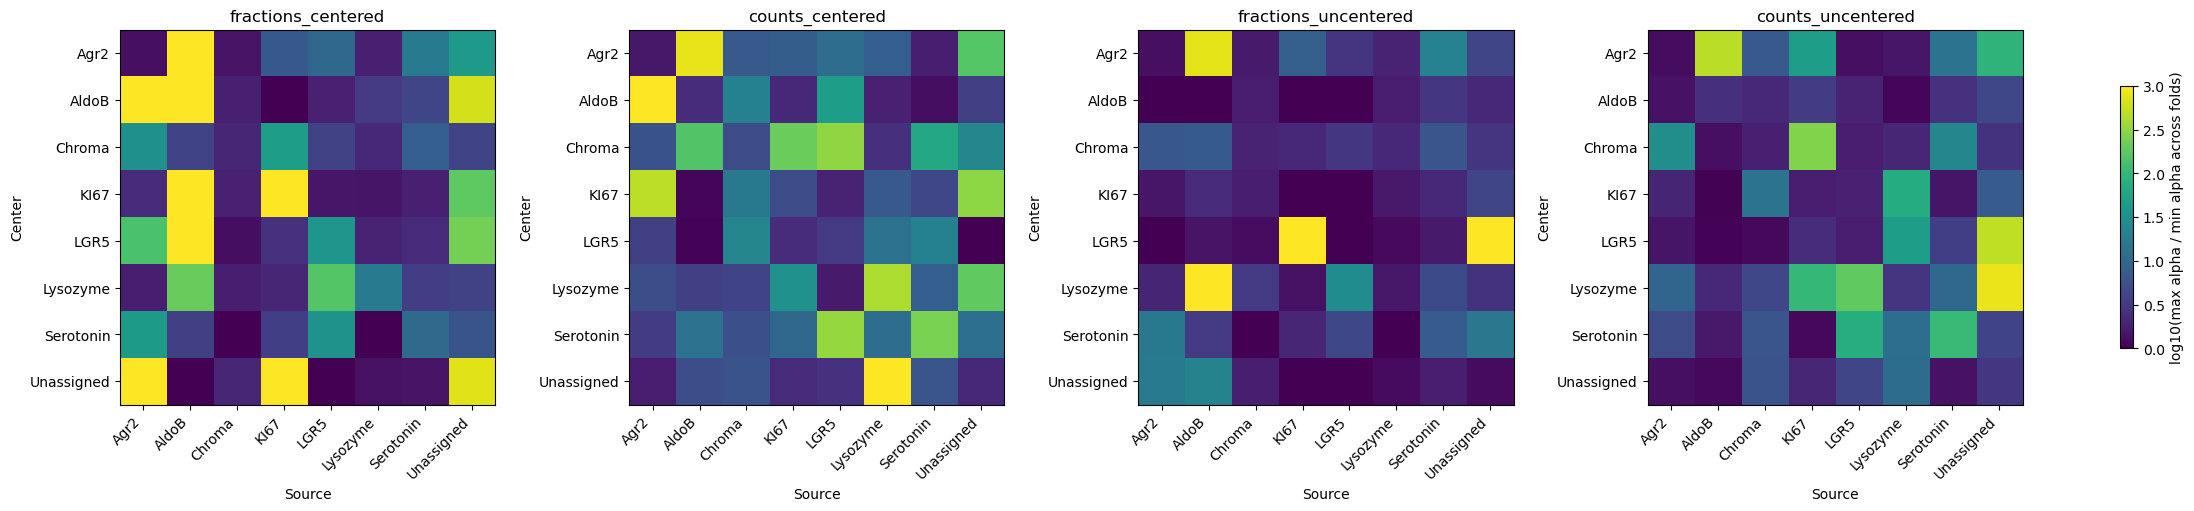

In [8]:
common_N = float(unique.N.median())
preference_rows = []
accommodation_rows = []
for (name,fold),m in models.items():
    local = m.design(dict(sample_all,N=common_N))@m.array(m.weights)*float(m.target_scale)
    for a,A in enumerate(identity_names):
        selected = identity==a
        context = pd.DataFrame(dict(organoid=orgs[selected],u=local[selected])).groupby('organoid').u.mean().mean()
        preference_rows.append(dict(name=name,fold=fold,center=A,N=common_N,reference_context_preference=context,
            center_coefficient=m.coefficients([common_N])['center'][0,a]))
    accommodation_rows.extend(dict(name=name,fold=fold,N=n,strength=v) for n,v in zip(common_ns,m.strength(common_ns)))
preferences = pd.DataFrame(preference_rows)
accommodation = pd.DataFrame(accommodation_rows)
preferences.to_csv(OUTPUT_DIR/'common_context_preferences.csv',index=False)
accommodation.to_csv(OUTPUT_DIR/'accommodation.csv',index=False)
fig,axes = plt.subplots(1,3,figsize=(17,4.5))
for name,shift in zip(model_names,[-.3,-.1,.1,.3]):
    for ax,column,title in zip(axes[:2],['center_coefficient','reference_context_preference'],
                               ['Raw center coefficient',f'Full local preference at common contexts, N={common_N:g}']):
        d = preferences[preferences.name==name].groupby('center')[column].agg(['mean','std']).reindex(identity_names)
        ax.errorbar(np.arange(t)+shift,d['mean'],yerr=d['std'],fmt='o',ms=4,capsize=2,color=colors[name],label=name)
        ax.set_xticks(np.arange(t),identity_names,rotation=45,ha='right')
        ax.set(title=title,ylabel='Residual mean-curvature units')
    for fold,d in accommodation[accommodation.name==name].groupby('fold'):
        axes[2].plot(d.N,d.strength,color=colors[name],alpha=.55)
axes[0].legend(fontsize=8)
axes[2].set(xscale='log',xlabel='N',ylabel='Accommodation strength',title='Every fitted fold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR/'preferences_and_accommodation.png',dpi=160)
plt.show()
fig,axes = plt.subplots(1,4,figsize=(22,5),layout='constrained')
for ax,name in zip(axes,model_names):
    table = parameters[parameters.name==name].drop_duplicates(['fold','center','source']).groupby(['center','source']).alpha.agg(['min','max'])
    matrix = np.log10(table['max']/table['min']).unstack().reindex(index=identity_names,columns=identity_names)
    im = ax.imshow(matrix,vmin=0,vmax=3,cmap='viridis')
    ax.set_xticks(np.arange(t),identity_names,rotation=45,ha='right')
    ax.set_yticks(np.arange(t),identity_names)
    ax.set(title=name,xlabel='Source',ylabel='Center')
fig.colorbar(im,ax=list(axes),label='log10(max alpha / min alpha across folds)',shrink=.7)
fig.savefig(OUTPUT_DIR/'saturation_stability.png',dpi=160,bbox_inches='tight')
plt.show()


## Test summary and saved handoff
Record matched accuracy, cross-fold consistency, optimizer convergence and representation details without drawing biological conclusions. The individual response and parameter tables remain available for the subsequent interpretation.

In [9]:
overall = summary[summary.region=='total'].set_index('name')
nonzero = stability.pivot(index=['center','source'],columns='name',values='near_zero')
common_pairs = nonzero.index[~nonzero.any(axis=1)]
matched = stability.set_index(['center','source']).loc[common_pairs].reset_index()
consistency = matched.groupby('name').agg(pairs=('relative_dispersion','size'),median_relative_dispersion=('relative_dispersion','median'),
    median_absolute_fold_rms=('absolute_fold_rms','median'),median_response_rms=('response_rms','median'),
    median_individual_dispersion=('individual_relative_dispersion','median'),unanimous_sign_pairs=('all_signs_agree','sum'),
    unanimous_trend_pairs=('trend_sign_agreement',lambda v:int((v==1).sum())))
consistency.to_csv(OUTPUT_DIR/'consistency_summary.csv')
parameter_once = parameters.drop_duplicates(['name','fold','center','source'])
alpha_bounds = parameter_once.groupby('name').alpha.agg(lower=lambda v:int((v<=.0201).sum()),upper=lambda v:int((v>=99.).sum()),total='size')
alpha_bounds.to_csv(OUTPUT_DIR/'saturation_bounds.csv')
training_audit = []
for record in run.records.itertuples():
    payload = load_bundle(run.directory/record.bundle)
    model = payload['model']
    info = payload['metrics']
    trials = json.loads((run.directory/'history'/f'{record.key}.json').read_text())
    if model.exposure_kind!='counts' or not model.accommodation or not model.pairs:raise ValueError('Wrong count model')
    if not model.center_response and np.any(model.array(model.reference)!=0):raise ValueError('Uncentered model subtracts a reference')
    if not info['optimizer']['success']:raise ValueError('Unconverged selected model')
    training_audit.append(dict(key=record.key,converged=True,center_response=model.center_response,
        optimizer_trials=len(trials),failed_trials=sum(not t.get('success',False) for t in trials),
        fit_seconds=info['fit_seconds'],pair_ridge=info['best']['penalty']['pair_ridge']))
(OUTPUT_DIR/'training_audit.json').write_text(json.dumps(training_audit,indent=2))
lines = ['# Count-exposure models: training and test record','',
    f'Completed {len(run.records)} new accommodated models on {len(membership)} saved folds, evaluated on {unique.organoid_str.nunique()} held-out organoids. The two count variants differ only in training-reference subtraction. Existing fraction models and FiLM were restored, not retrained. This record reports tests and descriptive comparisons; biological interpretation is deferred.','',
    '## Implemented model','',
    'Count exposure is x_B=(n_B_ring1+0.5*n_B_ring2)/1.5. There is no division by ring population, data-dependent exposure normalization, clipping, or learned distance parameter. Fraction models use source fractions in the same equation. All identities, including Unassigned, are counted.','',
    'Activation remains F(x)=tanh(alpha*x)/tanh(alpha). For counts x can exceed 1: F(1)=1 and its saturation ceiling is 1/tanh(alpha), not necessarily 1. The amplitude therefore denotes the response at one weighted-count unit, not a universal maximum response. Alpha has inverse weighted-count units rather than inverse fraction units. The numerical bounds [0.02,100], prior value 3, two initialization strengths, and penalty grid match the previous experiment; this does not imply a scale-invariant regularization comparison.','',
    'All other components are retained: constant center preferences, affine-log-N signed pair amplitudes, softplus-affine accommodation, weighted amplitude contrasts, baseline subtraction and exact mean-target preprocessing. The two rings always have the same marginal response sign at fixed N. Centered models subtract the fitting-only conditional activation mean; uncentered models set it to zero.','',
    'Absolute identity counts can implicitly reveal total neighborhood size. This is a deliberate reference experiment and does not demonstrate fate-only prediction.','',
    '## Held-out accuracy','', '| Model | Mean-curvature MSE | Organoid SEM |','| --- | ---: | ---: |']
for name in ['Baseline',*order]:
    d = overall.loc[name]
    lines.append(f"| {name} | {d['mean']:.7f} | {d['sem']:.7f} |")
lines += ['', 'Paired MSE differences, first model minus reference; conditional 95% organoid-bootstrap intervals:','']
for r in paired.itertuples():lines.append(f'- {r.model} minus {r.reference}: {r.difference:+.7f} [{r.ci_low:+.7f}, {r.ci_high:+.7f}].')
lines += ['', '## Descriptive fold consistency','',
    f'{int(support.supported.sum())}/{len(support)} pairs pass the shared count/fraction marginal support checks; {len(common_pairs)} have non-negligible RMS responses in all four models. The same contexts are used for all models and equally weighted by organoid.','',
    '| Model | Median relative dispersion | Absolute fold RMS | Response RMS | Individual-context dispersion | Unanimous sign | Unanimous trend | Alpha at lower/upper bound |',
    '| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |']
for name in model_names:
    r = consistency.loc[name]
    bounds = alpha_bounds.loc[name]
    lines.append(f'| {name} | {r.median_relative_dispersion:.3f} | {r.median_absolute_fold_rms:.5f} | {r.median_response_rms:.5f} | {r.median_individual_dispersion:.3f} | {int(r.unanimous_sign_pairs)}/{len(common_pairs)} | {int(r.unanimous_trend_pairs)}/{len(common_pairs)} | {int(bounds.lower)}/{int(bounds.upper)} of {int(bounds.total)} |')
lines += ['',
    'The readout is the pre-accommodation pair contribution relative to zero exposure, beta(N)*F(x). It is not a physical fate-replacement ablation. Zero is a mathematical anchor that may be outside support. The common support mask intersects both count and fraction exposure intervals and observed-N intervals across folds. This changes the diagnostic cohort from the earlier fraction-only report, so consistency numbers should be compared within this report. Overlapping training folds make agreement descriptive, not independent replication; some reference contexts were training data for a given fold. Only the outer-validation MSE measures held-out performance.','',
    '## Verification and artifacts','',
    f'All {len(training_audit)} selected fits converged. Across initialization/penalty/refit trials, {sum(a["failed_trials"] for a in training_audit)} failed out of {sum(a["optimizer_trials"] for a in training_audit)} attempts. Model constructors record the exposure representation and centering convention. Baselines, transformations, outer membership and inner membership are saved. Existing fraction/FiLM scores are reproduced within the tolerance recorded in reference_audit.json.','',
    'Saved tables include regional MSE, size-bin MSE, conditional paired comparisons, common support, individual fold response curves, amplitudes, saturation estimates, preferences, accommodation, and convergence audit. Full node predictions and sampled neighborhood indices/counts are saved alongside the figures.','',
    '## Figures','',
    f'- [Overall and regional accuracy](analysis/{OUTPUT_TAG}/mse_by_region.png).',
    f'- [Accuracy by N](analysis/{OUTPUT_TAG}/mse_by_size.png).',
    f'- [Consistency and support](analysis/{OUTPUT_TAG}/fold_consistency.png).',
    f'- [Pair response curves](analysis/{OUTPUT_TAG}/pair_response_curves.png).',
    f'- [Center preferences and accommodation](analysis/{OUTPUT_TAG}/preferences_and_accommodation.png).',
    f'- [Saturation variability](analysis/{OUTPUT_TAG}/saturation_stability.png).']
(run.directory/'REPORT.md').write_text('\n'.join(lines)+'\n')
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(new_count_models=len(run.records),folds=len(membership),organoids=int(unique.organoid_str.nunique()),supported_pairs=int(support.supported.sum())),indent=2))
print('Test record:',run.directory/'REPORT.md')
display(overall[['mean','sem']])
display(consistency)


Test record: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/pooled_interaction_training/counts_centered_vs_uncentered_20260930_121245/REPORT.md


,mean,sem
name,,
Baseline,0.004604,0.000084
FiLM,0.003776,0.000069
counts_centered,0.003906,0.000068
counts_uncentered,0.003887,0.000068
fractions_centered,0.003846,0.000067
fractions_uncentered,0.003817,0.000067


,pairs,median_relative_dispersion,median_absolute_fold_rms,median_response_rms,median_individual_dispersion,unanimous_sign_pairs,unanimous_trend_pairs
name,,,,,,,
counts_centered,64,0.255656,0.005088,0.021655,0.285326,45,40
counts_uncentered,64,0.157966,0.003228,0.020346,0.166673,44,51
fractions_centered,64,0.238137,0.004674,0.015706,0.251485,39,37
fractions_uncentered,64,0.148025,0.002722,0.016858,0.146599,52,49
